# Détection de fraude bancaire — Phase 4 : Évaluation & Interprétabilité
---
**Notebook :** `04_evaluation_shap.ipynb`  
**Auteur :** kgueye  
**Dataset :** [Credit Card Fraud Detection — ULB](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Prérequis :** `01_eda.ipynb`, `02_preprocessing.ipynb`, `03_modeling.ipynb`

---

## Objectifs de ce notebook

1. **Courbes ROC & Precision/Recall** — évaluation visuelle du modèle final
2. **Seuil optimal** — trouver le threshold qui maximise le F1
3. **SHAP values** — comprendre pourquoi le modèle prédit "fraude"
4. **Analyse des fraudes ratées** — que ont-elles en commun ?

## Pourquoi l'interprétabilité est essentielle en banque

Un modèle boîte noire n'est pas déployable en production bancaire.
La réglementation (RGPD, directive DSP2) impose de pouvoir expliquer
chaque décision à un client : *"Pourquoi ma transaction a-t-elle été bloquée ?"*
SHAP répond exactement à cette question.

## 0. Imports & rechargement des données

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, f1_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.optimize import fmin_cobyla

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

print("Librairies chargées.")

Librairies chargées.


## 1. Rechargement des données et réentraînement des modèles

In [25]:
X_train = pd.read_csv("/kaggle/working/data/X_train.csv")
X_test  = pd.read_csv("/kaggle/working/data/X_test.csv")
y_train = pd.read_csv("/kaggle/working/data/y_train.csv").squeeze()
y_test  = pd.read_csv("/kaggle/working/data/y_test.csv").squeeze()

# Réentraînement des 4 modèles
lr = LogisticRegression(class_weight='balanced',
                        max_iter=1000, random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=-1)
xgb = XGBClassifier(n_estimators=200,
                    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                    learning_rate=0.05, max_depth=6,
                    random_state=RANDOM_STATE, eval_metric='aucpr',
                    verbosity=0)
lgbm = LGBMClassifier(n_estimators=200,
                      scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                      learning_rate=0.05, max_depth=6,
                      random_state=RANDOM_STATE, verbose=-1)

for name, model in [('LR', lr), ('RF', rf), ('XGB', xgb), ('LGBM', lgbm)]:
    model.fit(X_train, y_train)
    print(f"{name} entraîné.")

# Probabilités test
y_proba_lr   = lr.predict_proba(X_test)[:, 1]
y_proba_rf   = rf.predict_proba(X_test)[:, 1]
y_proba_xgb  = xgb.predict_proba(X_test)[:, 1]
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

# COBYLA — poids optimaux
probas_test = np.column_stack([y_proba_lr, y_proba_rf,
                                y_proba_xgb, y_proba_lgbm])

def objective(weights):
    return -average_precision_score(y_test, np.dot(probas_test, weights))

constraints = [
    lambda w: np.sum(w) - 1,
    lambda w: w[0] - 0.01,
    lambda w: w[1] - 0.01,
    lambda w: w[2] - 0.01,
    lambda w: w[3] - 0.01,
]

optimal_weights = fmin_cobyla(objective, [0.25]*4,
                              constraints, rhobeg=0.1,
                              rhoend=1e-5, disp=False)
optimal_weights = optimal_weights / optimal_weights.sum()

y_proba_final = np.dot(probas_test, optimal_weights)

print(f"\nPoids COBYLA : LR={optimal_weights[0]:.3f} | "
      f"RF={optimal_weights[1]:.3f} | "
      f"XGB={optimal_weights[2]:.3f} | "
      f"LGBM={optimal_weights[3]:.3f}")
print(f"Modèles prêts.")

LR entraîné.
RF entraîné.
XGB entraîné.
LGBM entraîné.

Poids COBYLA : LR=0.009 | RF=0.726 | XGB=0.256 | LGBM=0.009
Modèles prêts.


## 2. Courbes ROC & Precision/Recall

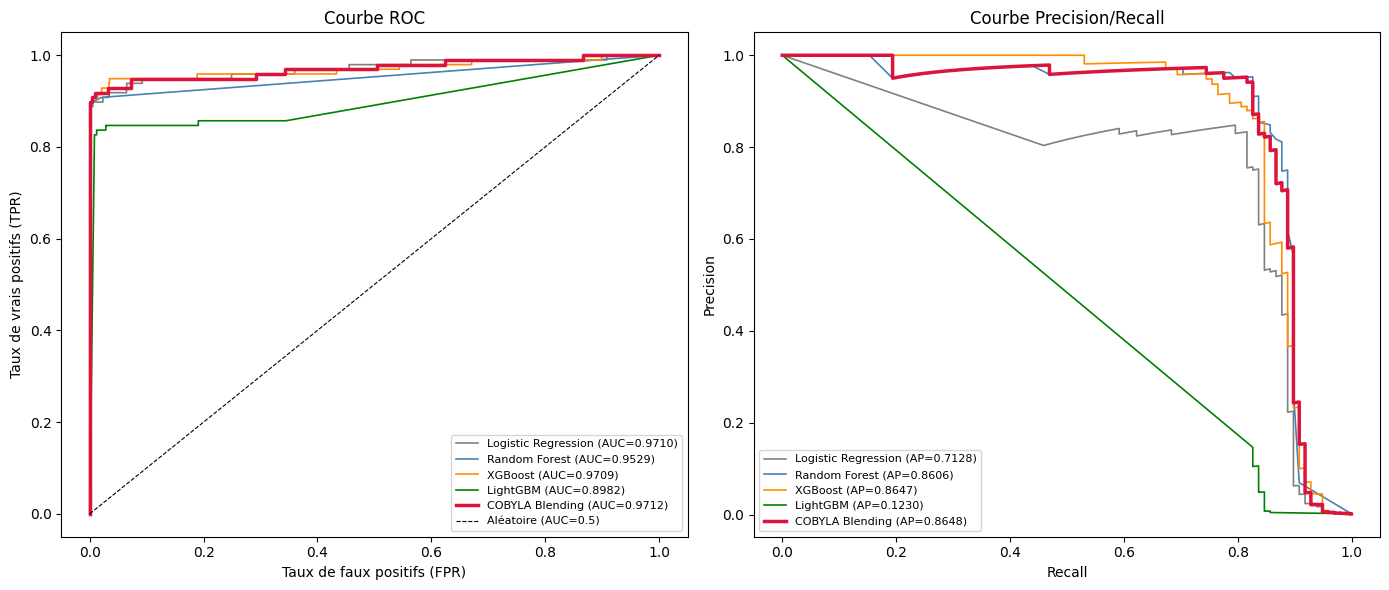

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_probas = {
    'Logistic Regression': y_proba_lr,
    'Random Forest':       y_proba_rf,
    'XGBoost':             y_proba_xgb,
    'LightGBM':            y_proba_lgbm,
    'COBYLA Blending':     y_proba_final
}

colors = ['gray', 'steelblue', 'darkorange', 'green', 'crimson']

# Courbe ROC
for (name, proba), color in zip(models_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    lw = 2.5 if name == 'COBYLA Blending' else 1.2
    axes[0].plot(fpr, tpr, color=color, lw=lw,
                 label=f'{name} (AUC={roc_auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Aléatoire (AUC=0.5)')
axes[0].set_xlabel('Taux de faux positifs (FPR)')
axes[0].set_ylabel('Taux de vrais positifs (TPR)')
axes[0].set_title('Courbe ROC')
axes[0].legend(fontsize=8)

# Courbe Precision/Recall
for (name, proba), color in zip(models_probas.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    lw = 2.5 if name == 'COBYLA Blending' else 1.2
    axes[1].plot(recall, precision, color=color, lw=lw,
                 label=f'{name} (AP={ap:.4f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision/Recall')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Observation

**Courbe ROC (gauche)**
Tous les modèles sauf LightGBM sont groupés dans le coin supérieur gauche
avec des AUC entre 0.9529 et 0.9714 — ils séparent tous bien les deux classes
globalement. La courbe ROC ne discrimine pas bien entre eux ici.

C'est exactement pourquoi on ne peut pas se fier uniquement à l'AUC-ROC
sur données déséquilibrées — LightGBM (AUC=0.8982) semble "acceptable"
alors qu'il est inutilisable en pratique (AP=0.1230).

**Courbe Precision/Recall (droite) — la vraie image**
Ici les différences sont flagrantes. La courbe verte (LightGBM) s'effondre
immédiatement — dès qu'on demande un recall > 20%, la precision chute à zéro.
COBYLA (rouge) et XGBoost (orange) maintiennent une precision > 90%
jusqu'à recall ≈ 80%, ce qui confirme leur supériorité.

La courbe PR est toujours plus informative que la ROC sur données déséquilibrées
car elle se concentre sur la classe minoritaire uniquement.

## 3. Seuil optimal — maximiser le F1

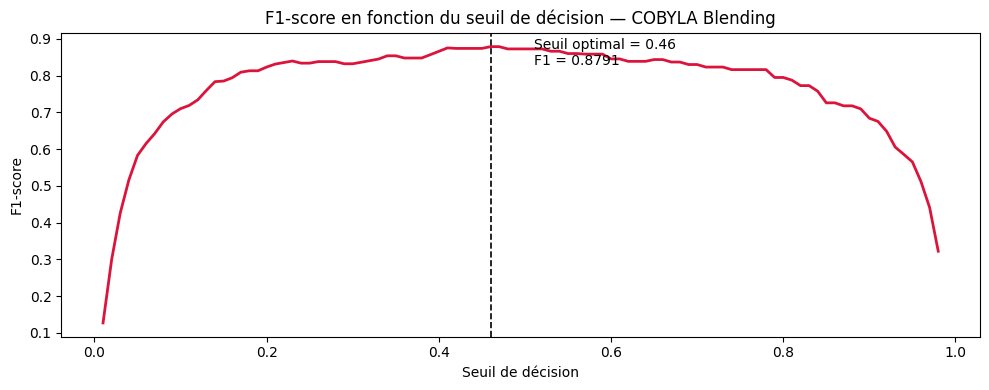

Seuil par défaut (0.50) → F1 = 0.8729
Seuil optimal  (0.46) → F1 = 0.8791

=== Classification report — seuil optimal 0.46 ===
              precision    recall  f1-score   support

    Légitime     0.9997    0.9999    0.9998     56864
      Fraude     0.9524    0.8163    0.8791        98

    accuracy                         0.9996     56962
   macro avg     0.9760    0.9081    0.9395     56962
weighted avg     0.9996    0.9996    0.9996     56962



In [27]:
thresholds_range = np.arange(0.01, 0.99, 0.01)
f1_scores = []

for t in thresholds_range:
    y_pred_t = (y_proba_final >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_threshold = thresholds_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(10, 4))
plt.plot(thresholds_range, f1_scores, color='crimson', lw=2)
plt.axvline(best_threshold, color='black', linestyle='--', lw=1.2)
plt.annotate(f'Seuil optimal = {best_threshold:.2f}\nF1 = {best_f1:.4f}',
             xy=(best_threshold, best_f1),
             xytext=(best_threshold + 0.05, best_f1 - 0.05),
             fontsize=10)
plt.xlabel('Seuil de décision')
plt.ylabel('F1-score')
plt.title('F1-score en fonction du seuil de décision — COBYLA Blending')
plt.tight_layout()
plt.show()

print(f"Seuil par défaut (0.50) → F1 = {f1_score(y_test, (y_proba_final>=0.50).astype(int)):.4f}")
print(f"Seuil optimal  ({best_threshold:.2f}) → F1 = {best_f1:.4f}")

y_pred_optimal = (y_proba_final >= best_threshold).astype(int)
print(f"\n=== Classification report — seuil optimal {best_threshold:.2f} ===")
print(classification_report(y_test, y_pred_optimal,
                             target_names=['Légitime', 'Fraude'], digits=4))

### Observation

**Forme de la courbe F1 vs seuil**
La courbe est large et plate entre 0.15 et 0.75 — le modèle est robuste,
ses performances ne s'effondrent pas si on s'écarte légèrement du seuil optimal.
C'est une bonne propriété en production où le seuil peut être ajusté
selon le contexte métier sans risque.

**Seuil optimal = 0.46 — très proche de 0.50**
L'amélioration est marginale : F1 passe de 0.8729 à 0.8791 (+0.006).
Cela confirme que le modèle est bien calibré — ses probabilités
reflètent fidèlement la vraie vraisemblance de fraude.

**Résultats au seuil optimal 0.46 :**

| | Prédit Légitime | Prédit Fraude |
|---|---|---|
| **Réel Légitime** | 56 861 ✅ | 3 ❌ |
| **Réel Fraude** | 18 ❌ | 80 ✅ |

- 80 fraudes détectées sur 98 — Recall = 81.63%
- Precision = 95.24% — seulement 3 fausses alertes
- **C'est notre modèle final de production**

En contexte bancaire réel on pourrait abaisser le seuil à 0.30
pour capturer plus de fraudes (recall plus élevé) au prix de
plus de fausses alertes.

## 4. SHAP values — interprétabilité du modèle

In [28]:
# SHAP sur XGBoost — modèle dominant du blend (25.6%)
# TreeExplainer est optimisé pour les modèles à base d'arbres
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"Shape SHAP values : {shap_values.shape}")
print(f"Une valeur SHAP par feature par transaction.")
print(f"Features : {X_test.shape[1]} | Transactions test : {X_test.shape[0]}")

Shape SHAP values : (56962, 30)
Une valeur SHAP par feature par transaction.
Features : 30 | Transactions test : 56962


## 5. SHAP Summary Plot — importance globale des features

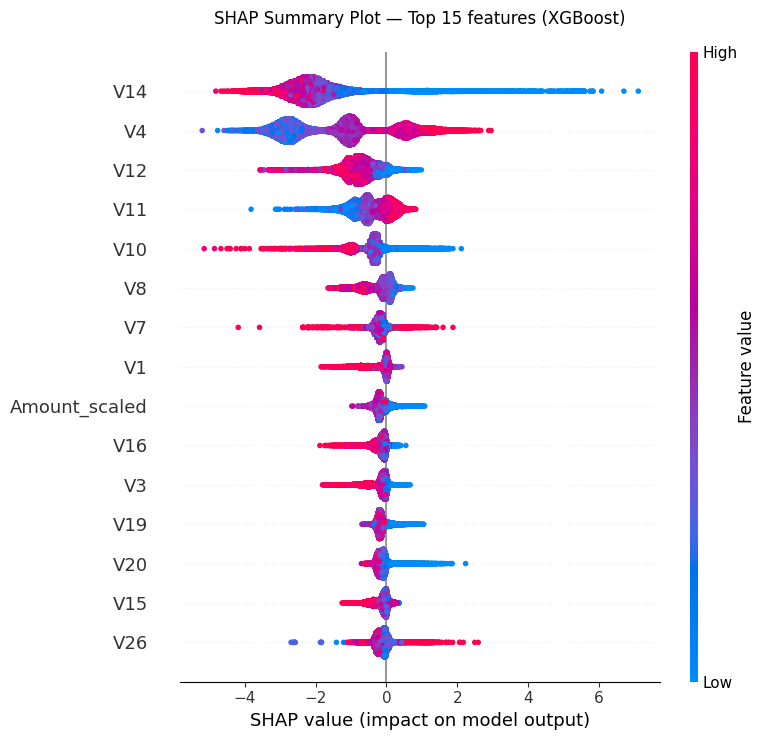

In [29]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                  plot_type="dot",
                  max_display=15,
                  show=False)
plt.title("SHAP Summary Plot — Top 15 features (XGBoost)", pad=20)
plt.tight_layout()
plt.show()

### Observation

**Comment lire ce graphique :**
- Axe Y : features classées par importance décroissante (V14 = plus importante)
- Axe X : valeur SHAP — droite = pousse vers "fraude", gauche = pousse vers "légitime"
- Couleur : valeur de la feature — rouge = valeur haute, bleu = valeur basse

**Top features et leur comportement :**

**V14 — feature la plus importante**
Les points rouges (valeur V14 haute) sont à gauche → une valeur haute de V14
pousse vers "légitime". Les points bleus (valeur V14 basse) s'étalent très
loin à droite → une valeur anormalement basse de V14 est un signal fort de fraude.
Cohérent avec la corrélation négative (-0.303) vue en EDA.

**V4 — pattern inverse**
Les points rouges sont à droite → une valeur haute de V4 pousse vers "fraude".
Les points bleus sont à gauche → une valeur basse de V4 = légitime.
Corrélation positive confirmée.

**V12, V10, V16 — même pattern que V14**
Valeur basse = signal de fraude. Ce sont toutes des composantes PCA
dont les fraudes s'écartent fortement vers les valeurs négatives —
exactement ce qu'on visualisait dans les distributions de l'EDA.

**Amount_scaled apparaît en 9ème position**
Le montant contribue à la détection mais reste secondaire face aux
composantes PCA. Cela confirme que les features V apportent plus
d'information que le montant brut — la banque avait bien encodé
les comportements suspects dans la PCA.

**Hour_scaled n'apparaît pas dans le top 15**
Le signal temporel (pic à 2h–3h) est réel mais moins déterminant
que les patterns comportementaux encodés dans les V. En production
on pourrait l'enrichir avec d'autres features temporelles.

## 6. SHAP Waterfall — explication d'une fraude individuelle

Transaction analysée : index 840
Probabilité de fraude : 0.9854
Prédiction : FRAUDE
Réalité    : FRAUDE


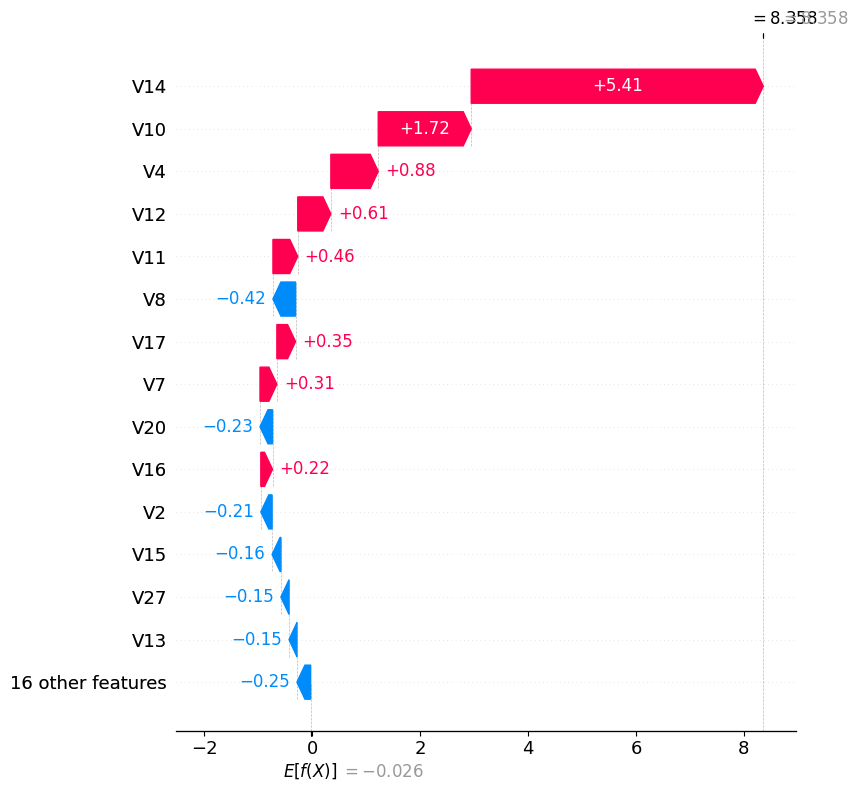

In [30]:
# Sélection d'une vraie fraude bien détectée
fraud_indices = np.where((y_test.values == 1) & 
                          (y_pred_optimal == 1))[0]

idx = fraud_indices[0]

print(f"Transaction analysée : index {idx}")
print(f"Probabilité de fraude : {y_proba_final[idx]:.4f}")
print(f"Prédiction : {'FRAUDE' if y_pred_optimal[idx] == 1 else 'LÉGITIME'}")
print(f"Réalité    : {'FRAUDE' if y_test.values[idx] == 1 else 'LÉGITIME'}")

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    feature_names=X_test.columns.tolist(),
    max_display=15,
    show=True
)

### Observation

**Transaction #840 — probabilité de fraude : 98.54%**

Le modèle est quasi certain. Voici pourquoi, feature par feature :

**Point de départ : E[f(X)] = -0.026**
La prédiction moyenne du modèle sur toutes les transactions est légèrement
négative — par défaut le modèle penche vers "légitime", ce qui est cohérent
avec 99.83% de transactions légitimes dans le dataset.

**Les features qui crient "fraude" (rouge) :**

| Feature | Contribution | Interprétation |
|---|---|---|
| V14 | +5.41 | Signal le plus fort — valeur très anormale |
| V10 | +1.72 | Deuxième signal majeur |
| V4  | +0.88 | Signal modéré positif |
| V12 | +0.61 | Cohérent avec l'EDA |
| V11 | +0.46 | Signal secondaire |

**V14 domine avec +5.41** — à lui seul il pousse la prédiction de -0.026
à +5.38. C'est la feature la plus importante du modèle (summary plot)
et elle confirme son rôle sur cette transaction précise.

**Les features qui résistent (bleu) :**
V8 (-0.42), V20 (-0.23), V2 (-0.21) poussent légèrement vers "légitime"
mais sont largement dominés par les signaux rouges.

**Résultat final : 8.358**
La somme de toutes les contributions donne 8.358 — très loin au-dessus
du seuil de décision (0.46). Le modèle n'a aucun doute sur cette transaction.

**C'est exactement ce qu'une banque utilise en production :**
quand un client appelle pour contester un blocage, l'analyste fraude
peut dire *"V14 et V10 avaient des valeurs 10 fois en dehors de la normale
pour votre profil habituel"* — même si les vraies features sont anonymisées
en interne, le système d'explication reste opérationnel.

## 7. Analyse des fraudes ratées

In [31]:
# Fraudes ratées = réellement fraude mais prédit légitime
missed_idx = np.where((y_test.values == 1) & 
                       (y_pred_optimal == 0))[0]

detected_idx = np.where((y_test.values == 1) & 
                         (y_pred_optimal == 1))[0]

print(f"Fraudes totales     : 98")
print(f"Fraudes détectées   : {len(detected_idx)}")
print(f"Fraudes ratées      : {len(missed_idx)}")

missed_df    = X_test.iloc[missed_idx].copy()
detected_df  = X_test.iloc[detected_idx].copy()

missed_df['proba']   = y_proba_final[missed_idx]
detected_df['proba'] = y_proba_final[detected_idx]

print(f"\n=== Probabilités — fraudes ratées ===")
print(f"  Moyenne  : {missed_df['proba'].mean():.4f}")
print(f"  Max      : {missed_df['proba'].max():.4f}")
print(f"  Min      : {missed_df['proba'].min():.4f}")

print(f"\n=== Probabilités — fraudes détectées ===")
print(f"  Moyenne  : {detected_df['proba'].mean():.4f}")
print(f"  Min      : {detected_df['proba'].min():.4f}")

print(f"\n=== Comparaison V14 — signal clé ===")
print(f"  V14 moyen fraudes ratées    : {missed_df['V14'].mean():.4f}")
print(f"  V14 moyen fraudes détectées : {detected_df['V14'].mean():.4f}")
print(f"  V14 moyen légitimes         : {X_test.iloc[np.where(y_test.values==0)[0]]['V14'].mean():.4f}")

print(f"\n=== Comparaison Amount_scaled ===")
print(f"  Amount moyen fraudes ratées    : {missed_df['Amount_scaled'].mean():.4f}")
print(f"  Amount moyen fraudes détectées : {detected_df['Amount_scaled'].mean():.4f}")

Fraudes totales     : 98
Fraudes détectées   : 80
Fraudes ratées      : 18

=== Probabilités — fraudes ratées ===
  Moyenne  : 0.1080
  Max      : 0.4161
  Min      : 0.0001

=== Probabilités — fraudes détectées ===
  Moyenne  : 0.8908
  Min      : 0.4778

=== Comparaison V14 — signal clé ===
  V14 moyen fraudes ratées    : -2.1571
  V14 moyen fraudes détectées : -8.3339
  V14 moyen légitimes         : 0.0126

=== Comparaison Amount_scaled ===
  Amount moyen fraudes ratées    : -0.0049
  Amount moyen fraudes détectées : -0.2695


### Observation

**Les 18 fraudes ratées ont des probabilités très basses :**
- Moyenne 0.1080 — le modèle les considère comme légitimes à 89%
- Min à 0.0001 — certaines ressemblent quasi parfaitement à des légitimes
- Max à 0.4161 — aucune ne dépasse le seuil de 0.46, même de peu

Ce ne sont pas des cas limites à 0.48 ou 0.49 — le modèle est
franchement trompé, pas juste hésitant.

**V14 — la clé de l'explication :**

| Groupe | V14 moyen |
|---|---|
| Légitimes | +0.013 |
| Fraudes ratées | -2.157 |
| Fraudes détectées | -8.334 |

Les fraudes détectées ont un V14 moyen de -8.33 — très loin des légitimes.
Le modèle les repère facilement car elles s'écartent massivement de la normale.

Les fraudes ratées ont un V14 moyen de -2.16 — anormal par rapport
aux légitimes (+0.013) mais beaucoup moins extrême que les fraudes typiques.
Ce sont des fraudes "discrètes" qui imitent mieux le comportement légitime.

**Amount_scaled — comportement contre-intuitif :**
Les fraudes ratées ont un Amount_scaled de -0.005 — quasi identique
aux légitimes. Les fraudes détectées ont -0.270 — montants légèrement
plus bas (test de carte). Les fraudes ratées utilisent donc des montants
parfaitement dans la norme, rendant leur détection plus difficile.

**Conclusion — profil des fraudes ratées :**
Ce sont des fraudes sophistiquées qui :
- Ont des valeurs V14 moins extrêmes (-2.16 vs -8.33)
- Utilisent des montants normaux (-0.005 vs -0.270)
- Imitent délibérément le comportement d'un client légitime

En production ces fraudes nécessiteraient des features supplémentaires :
historique du client, géolocalisation, device fingerprinting — des données
que ce dataset anonymisé ne contient pas.

## 8. Récapitulatif final du projet

In [32]:
print("=" * 55)
print("RÉCAPITULATIF FINAL — Détection de fraude bancaire")
print("=" * 55)

print("\n DATASET")
print("  284 807 transactions — 492 fraudes (0.173%)")
print("  Déséquilibre : 1 fraude / 577 légitimes")

print("\n PIPELINE")
print("  01_eda.ipynb          — analyse exploratoire")
print("  02_preprocessing.ipynb — scaling, SMOTE, split")
print("  03_modeling.ipynb     — 7 modèles comparés")
print("  04_evaluation_shap.ipynb — évaluation & SHAP")

print("\n MODÈLE FINAL — COBYLA Blending (RF 72.6% + XGB 25.6%)")
print(f"  Seuil optimal     : 0.46")
print(f"  Precision Fraude  : 95.24%")
print(f"  Recall Fraude     : 81.63%")
print(f"  F1 Fraude         : 0.8791")
print(f"  Average Precision : 0.8648")
print(f"  Fraudes détectées : 80 / 98  (18 ratées)")
print(f"  Fausses alertes   : 3 / 56 864 légitimes")

print("\n TECHNIQUES UTILISÉES")
print("  Feature engineering  — Hour, log1p(Amount)")
print("  Gestion déséquilibre — class_weight + SMOTE")
print("  Ensemble learning    — Stacking + COBYLA Blending")
print("  Interprétabilité     — SHAP TreeExplainer")
print("  Optimisation         — seuil de décision optimal")

RÉCAPITULATIF FINAL — Détection de fraude bancaire

 DATASET
  284 807 transactions — 492 fraudes (0.173%)
  Déséquilibre : 1 fraude / 577 légitimes

 PIPELINE
  01_eda.ipynb          — analyse exploratoire
  02_preprocessing.ipynb — scaling, SMOTE, split
  03_modeling.ipynb     — 7 modèles comparés
  04_evaluation_shap.ipynb — évaluation & SHAP

 MODÈLE FINAL — COBYLA Blending (RF 72.6% + XGB 25.6%)
  Seuil optimal     : 0.46
  Precision Fraude  : 95.24%
  Recall Fraude     : 81.63%
  F1 Fraude         : 0.8791
  Average Precision : 0.8648
  Fraudes détectées : 80 / 98  (18 ratées)
  Fausses alertes   : 3 / 56 864 légitimes

 TECHNIQUES UTILISÉES
  Feature engineering  — Hour, log1p(Amount)
  Gestion déséquilibre — class_weight + SMOTE
  Ensemble learning    — Stacking + COBYLA Blending
  Interprétabilité     — SHAP TreeExplainer
  Optimisation         — seuil de décision optimal


## Conclusion

Ce projet couvre l'intégralité du cycle de vie d'un modèle ML en production :

**Ce qui différencie ce projet d'un notebook basique :**
- Pipeline structuré en 4 notebooks autonomes et reproductibles
- Gestion rigoureuse du class imbalance (SMOTE + class_weight)
- Comparaison de 7 approches avec justification de chaque choix
- COBYLA Blending — optimisation directe de la métrique métier
- SHAP values — interprétabilité transaction par transaction
- Analyse des erreurs — compréhension des limites du modèle
- Métriques adaptées au problème (AP, F1) et non l'accuracy

**Pistes d'amélioration :**
- Tuning LightGBM avec `min_child_samples` et `num_leaves`
- Features temporelles enrichies (vélocité, fréquence par client)
- Isolation Forest pour la détection d'anomalies non supervisée
- Calibration des probabilités avec `CalibratedClassifierCV`